In [1]:
!pip install skyfield sgp4 numpy pandas matplotlib ortools
!pip install plotly folium networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 12.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage

In [2]:
!pip install skyfield sgp4

In [3]:
from skyfield.api import load, Topos, EarthSatellite
from datetime import timedelta

# -----------------------------
# 1. Load Timescale
# -----------------------------

ts = load.timescale()

# -----------------------------
# 2. Load ISS TLE from CelesTrak
# -----------------------------

url = "https://celestrak.org/NORAD/elements/gp.php?CATNR=25544&FORMAT=TLE"
satellites = load.tle_file(url)
print("TLE data loaded.")

# Find ISS satellite
iss = None
for sat in satellites:
    if "ISS" in sat.name:
        iss = sat
        break

print("Satellite selected:", iss.name)


# -----------------------------
# 3. Define Ground Station (Bengaluru)
# -----------------------------
bengaluru = Topos(latitude_degrees=13.035304,
                  longitude_degrees=77.512376,
                  elevation_m=904)

# -----------------------------
# 4. Define Time Window (Next 24 Hours)
# -----------------------------
t0 = ts.now()
t1 = ts.utc(t0.utc_datetime() + timedelta(days=1))

# -----------------------------
# 5. Compute Pass Events
# -----------------------------
t, events = iss.find_events(bengaluru, t0, t1, altitude_degrees=10.0)

# events:
# 0 = rise above 10°
# 1 = maximum elevation
# 2 = set below 10°

print("\nUpcoming ISS Passes over Bengaluru (Next 24 hrs):\n")

for ti, event in zip(t, events):
    name = ("Rise above 10°", "Maximum elevation", "Set below 10°")[event]
    print(ti.utc_strftime('%Y-%m-%d %H:%M:%S UTC'), name)




[#################################] 100% gp.php


TLE data loaded.
Satellite selected: ISS (ZARYA)

Upcoming ISS Passes over Bengaluru (Next 24 hrs):

2026-03-03 15:22:54 UTC Rise above 10°
2026-03-03 15:26:15 UTC Maximum elevation
2026-03-03 15:29:36 UTC Set below 10°
2026-03-04 01:17:48 UTC Rise above 10°
2026-03-04 01:20:26 UTC Maximum elevation
2026-03-04 01:23:05 UTC Set below 10°
2026-03-04 02:55:30 UTC Rise above 10°
2026-03-04 02:57:03 UTC Maximum elevation
2026-03-04 02:58:36 UTC Set below 10°


In [4]:
import pandas as pd

# -----------------------------
# Convert events into pass windows
# -----------------------------
passes = []

current_pass = {}

for ti, event in zip(t, events):

    if event == 0:  # Rise
        current_pass = {}
        current_pass["start_time"] = ti.utc_datetime()

    elif event == 1:  # Max elevation
        difference = iss - bengaluru
        topocentric = difference.at(ti)
        alt, az, distance = topocentric.altaz()
        current_pass["max_elevation_deg"] = alt.degrees

    elif event == 2:  # Set
        current_pass["end_time"] = ti.utc_datetime()

        duration = (current_pass["end_time"] -
                    current_pass["start_time"]).total_seconds() / 60.0

        current_pass["duration_minutes"] = duration
        current_pass["satellite"] = iss.name
        current_pass["station"] = "Bengaluru"

        passes.append(current_pass)

# -----------------------------
# Create DataFrame
# -----------------------------
df_passes = pd.DataFrame(passes)

print("\nStructured Pass Windows:\n")
print(df_passes)

# Optional: Save to CSV
df_passes.to_csv("iss_passes_bengaluru.csv", index=False)


Structured Pass Windows:

                        start_time  max_elevation_deg  \
0 2026-03-03 15:22:54.008977+00:00          64.402084   
1 2026-03-04 01:17:47.500588+00:00          21.686834   
2 2026-03-04 02:55:29.530751+00:00          12.712870   

                          end_time  duration_minutes    satellite    station  
0 2026-03-03 15:29:36.125444+00:00          6.701941  ISS (ZARYA)  Bengaluru  
1 2026-03-04 01:23:04.644633+00:00          5.285734  ISS (ZARYA)  Bengaluru  
2 2026-03-04 02:58:36.435470+00:00          3.115079  ISS (ZARYA)  Bengaluru  


In [5]:
import requests
import pandas as pd
from skyfield.api import load, Topos, EarthSatellite
from datetime import timedelta

# -----------------------------
# Load Timescale
# -----------------------------
ts = load.timescale()

# -----------------------------
# Ground Station (Bengaluru)
# -----------------------------
bengaluru = Topos(latitude_degrees=13.035304,
                  longitude_degrees=77.512376,
                  elevation_m=904)

# -----------------------------
# ISRO Satellite NORAD IDs
# -----------------------------
sat_ids = {
    "RISAT-2B": 44233,
    "RISAT-2BR1": 44804,
    "Oceansat-2": 35931,
    "Scatsat-1": 41752,
    "Resourcesat-2A": 41877,
    "Cartosat-2C": 41748,
    "Cartosat-2D": 41948,
    "EMISAT": 44078,
    "HySIS": 43719
}
# -----------------------------
# Time Window (Next 24 Hours)
# -----------------------------
t0 = ts.now()
t1 = ts.utc(t0.utc_datetime() + timedelta(days=1))

all_passes = []

for sat_name, norad_id in sat_ids.items():

    print(f"\nLoading TLE for {sat_name}...")

    url = f"https://celestrak.org/NORAD/elements/gp.php?CATNR={norad_id}&FORMAT=TLE"
    response = requests.get(url).text.strip().splitlines()

    if len(response) < 3:
        print(f"⚠ Could not load TLE for {sat_name}")
        continue

    name = response[0].strip()
    line1 = response[1].strip()
    line2 = response[2].strip()

    satellite = EarthSatellite(line1, line2, name, ts)

    # Find visibility events
    t, events = satellite.find_events(bengaluru, t0, t1, altitude_degrees=10.0)

    current_pass = {}

    for ti, event in zip(t, events):

        if event == 0:  # Rise
            current_pass = {}
            current_pass["start_time"] = ti.utc_datetime()

        elif event == 1:  # Max elevation
            difference = satellite - bengaluru
            topocentric = difference.at(ti)
            alt, az, distance = topocentric.altaz()
            current_pass["max_elevation_deg"] = alt.degrees

        elif event == 2:  # Set
            current_pass["end_time"] = ti.utc_datetime()

            duration = (current_pass["end_time"] -
                        current_pass["start_time"]).total_seconds() / 60.0

            current_pass["duration_minutes"] = duration
            current_pass["satellite"] = sat_name
            current_pass["station"] = "Bengaluru"

            all_passes.append(current_pass)

# -----------------------------
# Combined DataFrame
# -----------------------------
df_all = pd.DataFrame(all_passes)

print("\nAll ISRO Satellite Passes (Next 24 hrs):\n")
print(df_all)

df_all.to_csv("isro_satellite_passes.csv", index=False)


Loading TLE for RISAT-2B...

Loading TLE for RISAT-2BR1...

Loading TLE for Oceansat-2...

Loading TLE for Scatsat-1...

Loading TLE for Resourcesat-2A...

Loading TLE for Cartosat-2C...

Loading TLE for Cartosat-2D...

Loading TLE for EMISAT...

Loading TLE for HySIS...

All ISRO Satellite Passes (Next 24 hrs):

                         start_time  max_elevation_deg  \
0  2026-03-03 12:06:27.982943+00:00          80.400850   
1  2026-03-03 13:50:15.849424+00:00          11.416055   
2  2026-03-04 01:51:02.055772+00:00          48.874592   
3  2026-03-04 03:33:05.761885+00:00          21.256664   
4  2026-03-04 10:24:01.021072+00:00          18.651145   
5  2026-03-03 15:28:40.298106+00:00          13.568356   
6  2026-03-03 17:01:33.446594+00:00          18.346030   
7  2026-03-04 04:45:16.713931+00:00          52.178514   
8  2026-03-03 11:17:31.493459+00:00          38.647182   
9  2026-03-03 13:00:48.531824+00:00          16.643699   
10 2026-03-04 00:01:11.397776+00:00          7

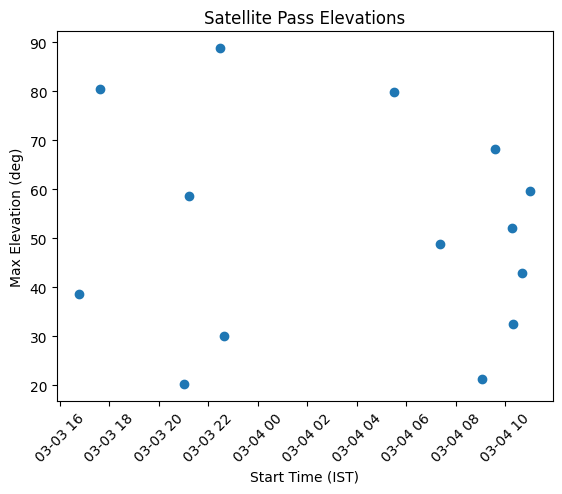

In [6]:
# Start from your main dataframe
df = df_all.copy()

# Sort properly
df = df.sort_values(by="start_time").reset_index(drop=True)

# Convert to IST
import pytz
ist = pytz.timezone("Asia/Kolkata")

df["start_time_IST"] = df["start_time"].dt.tz_convert(ist)
df["end_time_IST"] = df["end_time"].dt.tz_convert(ist)

# Filter elevation
df = df[df["max_elevation_deg"] >= 20]

# Get next pass per satellite
next_passes = (
    df.sort_values("start_time")
      .groupby("satellite")
      .first()
      .reset_index()
)

# Export CSV
df.to_csv("isro_passes_next_24h.csv", index=False)

# Plot
import matplotlib.pyplot as plt

plt.scatter(df["start_time_IST"], df["max_elevation_deg"])
plt.xticks(rotation=45)
plt.xlabel("Start Time (IST)")
plt.ylabel("Max Elevation (deg)")
plt.title("Satellite Pass Elevations")
plt.show()

In [7]:
# Greedy Single-Antenna Scheduler

# -----------------------------
# Start from cleaned master dataframe
# -----------------------------

df = df_all.copy()

# Filter useful passes (>= 20° elevation)
df = df[df["max_elevation_deg"] >= 20]

# Sort chronologically
df = df.sort_values(by="start_time").reset_index(drop=True)


# -----------------------------
# Greedy Single-Antenna Scheduler
# -----------------------------

scheduled_rows = []
antenna_free_time = None

for _, row in df.iterrows():

    if antenna_free_time is None:
        scheduled_rows.append(row)
        antenna_free_time = row["end_time"]

    elif row["start_time"] >= antenna_free_time:
        scheduled_rows.append(row)
        antenna_free_time = row["end_time"]

    # else: conflict → skip


# Convert to DataFrame
df_scheduled = pd.DataFrame(scheduled_rows).reset_index(drop=True)


# -----------------------------
# Results
# -----------------------------

print("\nScheduled Passes (1 Antenna - Greedy):\n")
print(df_scheduled[
    ["satellite", "start_time", "end_time",
     "duration_minutes", "max_elevation_deg"]
])

print("\nTotal Requested Passes:", len(df))
print("Total Scheduled Passes:", len(df_scheduled))

print("\nTotal Contact Time Served (minutes):",
      round(df_scheduled["duration_minutes"].sum(), 2))


Scheduled Passes (1 Antenna - Greedy):

         satellite                       start_time  \
0       Oceansat-2 2026-03-03 11:17:31.493459+00:00   
1         RISAT-2B 2026-03-03 12:06:27.982943+00:00   
2      Cartosat-2D 2026-03-03 15:30:47.575750+00:00   
3           EMISAT 2026-03-03 15:44:13.287413+00:00   
4   Resourcesat-2A 2026-03-03 16:58:09.242310+00:00   
5       Oceansat-2 2026-03-04 00:01:11.397776+00:00   
6         RISAT-2B 2026-03-04 01:51:02.055772+00:00   
7         RISAT-2B 2026-03-04 03:33:05.761885+00:00   
8           EMISAT 2026-03-04 04:05:24.942958+00:00   
9       RISAT-2BR1 2026-03-04 04:45:16.713931+00:00   
10           HySIS 2026-03-04 05:10:18.538737+00:00   
11  Resourcesat-2A 2026-03-04 05:30:40.366267+00:00   

                           end_time  duration_minutes  max_elevation_deg  
0  2026-03-03 11:28:07.530846+00:00         10.600623          38.647182  
1  2026-03-03 12:14:57.404803+00:00          8.490364          80.400850  
2  2026-03-03 15:3

In [8]:
# -----------------------------
# Prepare Data
# -----------------------------

from datetime import timedelta

df = df_all.copy()

# Filter useful passes
df = df[df["max_elevation_deg"] >= 20]

# SORT BY END TIME (Optimal Strategy)
df = df.sort_values(by="end_time").reset_index(drop=True)


# -----------------------------
# Configuration
# -----------------------------

switch_delay = timedelta(minutes=3)   # <-- Change delay here if needed


# -----------------------------
# 2-Antenna End-Time Scheduler (With Delay)
# -----------------------------

scheduled_rows = []

antenna1_free_time = None
antenna2_free_time = None

for _, row in df.iterrows():

    # Check Antenna 1
    if (antenna1_free_time is None) or (
        row["start_time"] >= antenna1_free_time
    ):
        antenna1_free_time = row["end_time"] + switch_delay
        row_copy = row.copy()
        row_copy["assigned_antenna"] = "Antenna-1"
        scheduled_rows.append(row_copy)

    # Else check Antenna 2
    elif (antenna2_free_time is None) or (
        row["start_time"] >= antenna2_free_time
    ):
        antenna2_free_time = row["end_time"] + switch_delay
        row_copy = row.copy()
        row_copy["assigned_antenna"] = "Antenna-2"
        scheduled_rows.append(row_copy)

    # Else both busy → skip


# Convert to DataFrame
df_scheduled = pd.DataFrame(scheduled_rows).reset_index(drop=True)


# -----------------------------
# Results
# -----------------------------

print("\nScheduled Passes (2 Antennas - End-Time Optimal + 3 min Delay):\n")

print(df_scheduled[
    ["satellite",
     "start_time",
     "end_time",
     "duration_minutes",
     "max_elevation_deg",
     "assigned_antenna"]
])

print("\nTotal Requested Passes:", len(df))
print("Total Scheduled Passes:", len(df_scheduled))

print("\nTotal Contact Time Served (minutes):",
      round(df_scheduled["duration_minutes"].sum(), 2))


Scheduled Passes (2 Antennas - End-Time Optimal + 3 min Delay):

         satellite                       start_time  \
0       Oceansat-2 2026-03-03 11:17:31.493459+00:00   
1         RISAT-2B 2026-03-03 12:06:27.982943+00:00   
2      Cartosat-2D 2026-03-03 15:30:47.575750+00:00   
3           EMISAT 2026-03-03 15:44:13.287413+00:00   
4   Resourcesat-2A 2026-03-03 16:58:09.242310+00:00   
5            HySIS 2026-03-03 17:06:48.989240+00:00   
6       Oceansat-2 2026-03-04 00:01:11.397776+00:00   
7         RISAT-2B 2026-03-04 01:51:02.055772+00:00   
8         RISAT-2B 2026-03-04 03:33:05.761885+00:00   
9           EMISAT 2026-03-04 04:05:24.942958+00:00   
10      RISAT-2BR1 2026-03-04 04:45:16.713931+00:00   
11     Cartosat-2D 2026-03-04 04:48:34.383549+00:00   
12           HySIS 2026-03-04 05:10:18.538737+00:00   
13  Resourcesat-2A 2026-03-04 05:30:40.366267+00:00   

                           end_time  duration_minutes  max_elevation_deg  \
0  2026-03-03 11:28:07.530846+00

In [9]:
# -----------------------------
# Ground Station Performance Report
# -----------------------------

from datetime import timedelta

# Observation window
window_start = df["start_time"].min()
window_end = df["end_time"].max()

total_window_minutes = (window_end - window_start).total_seconds() / 60

# Number of antennas
num_antennas = 2

# Total possible antenna time (capacity)
total_capacity_minutes = total_window_minutes * num_antennas

# Scheduled contact time
total_contact_minutes = df_scheduled["duration_minutes"].sum()

# Rejected passes
rejected_passes = len(df) - len(df_scheduled)

# Utilization percentage
utilization = (total_contact_minutes / total_capacity_minutes) * 100


# -----------------------------
# Print Performance Report
# -----------------------------

print("\n==============================")
print("Ground Station Performance Report")
print("==============================")

print(f"Antennas: {num_antennas}")
print("Switch Delay: 3 minutes")

print(f"\nObservation Window: {window_start}  →  {window_end}")
print(f"Total Window Duration (minutes): {round(total_window_minutes,2)}")

print(f"\nTotal Requested Passes: {len(df)}")
print(f"Scheduled Passes: {len(df_scheduled)}")
print(f"Rejected Passes: {rejected_passes}")

print(f"\nTotal Contact Time Served (minutes): {round(total_contact_minutes,2)}")
print(f"Total Antenna Capacity (minutes): {round(total_capacity_minutes,2)}")

print(f"\nAntenna Utilization: {round(utilization,2)} %")
print("==============================")


Ground Station Performance Report
Antennas: 2
Switch Delay: 3 minutes

Observation Window: 2026-03-03 11:17:31.493459+00:00  →  2026-03-04 05:41:09.993229+00:00
Total Window Duration (minutes): 1103.64

Total Requested Passes: 14
Scheduled Passes: 14
Rejected Passes: 0

Total Contact Time Served (minutes): 121.35
Total Antenna Capacity (minutes): 2207.28

Antenna Utilization: 5.5 %


In [10]:
stations = {
    "Bengaluru": {
        "latitude": 13.0289,        # Bengaluru
        "longitude": 77.5770,
        "elevation_m": 920,         # Approx elevation of city
        "antennas": 5
    },
    "Lucknow": {
        "latitude": 26.8467,
        "longitude": 80.9462,
        "elevation_m": 123,
        "antennas": 3
    },
    "PortBlair": {
        "latitude": 11.6234,
        "longitude": 92.7265,
        "elevation_m": 15,
        "antennas": 3
    },
    "Mauritius": {
        "latitude": -20.3484,       # Near Plaine Corail tracking region
        "longitude": 57.5522,
        "elevation_m": 60,
        "antennas": 4
    },
    "Sriharikota": {
        "latitude": 13.7330,
        "longitude": 80.2350,
        "elevation_m": 5,
        "antennas": 4
    }
}

In [11]:
from skyfield.api import load, EarthSatellite, wgs84
from datetime import timedelta
import requests
import pandas as pd

# --------------------------------------------------
#  Load Timescale
# --------------------------------------------------
ts = load.timescale()

t0 = ts.now()
t1 = ts.from_datetime(t0.utc_datetime() + timedelta(days=1))

# --------------------------------------------------
#  Function to fetch TLE
# --------------------------------------------------
def fetch_tle(norad_id):
    url = f"https://celestrak.org/NORAD/elements/gp.php?CATNR={norad_id}&FORMAT=TLE"

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
    except:
        return None

    lines = response.text.strip().split("\n")

    if len(lines) < 3:
        return None

    return lines[0].strip(), lines[1].strip(), lines[2].strip()


# --------------------------------------------------
#  Generate passes for all satellites & stations
# --------------------------------------------------
all_passes = []

for sat_name, sat_id in sat_ids.items():

    tle = fetch_tle(sat_id)
    if tle is None:
        print(f"Skipping {sat_name} (TLE not found)")
        continue

    name, line1, line2 = tle
    satellite = EarthSatellite(line1, line2, name, ts)

    for station_name, station_data in stations.items():

        observer = wgs84.latlon(
            station_data["latitude"],
            station_data["longitude"],
            elevation_m=station_data["elevation_m"]
        )

        #  Corrected line here
        times, events = satellite.find_events(
            observer,
            t0,
            t1,
            altitude_degrees=10.0
        )

        # events: 0 = rise, 1 = culminate, 2 = set
        for i in range(len(events)):
            if events[i] == 0:  # rise event

                rise_time = times[i].utc_datetime()

                # find corresponding set event
                for j in range(i+1, len(events)):
                    if events[j] == 2:
                        set_time = times[j].utc_datetime()
                        duration = (set_time - rise_time).total_seconds()

                        all_passes.append({
                            "satellite": sat_name,
                            "station": station_name,
                            "start_time": rise_time,
                            "end_time": set_time,
                            "duration_sec": duration
                        })
                        break


# --------------------------------------------------
#  Convert to DataFrame
# --------------------------------------------------
df_passes = pd.DataFrame(all_passes)

if not df_passes.empty:
    df_passes = df_passes.sort_values("start_time").reset_index(drop=True)

print(df_passes.head())
print(f"\nTotal passes generated: {len(df_passes)}")

    satellite      station                       start_time  \
0  Oceansat-2    PortBlair 2026-03-03 11:15:58.102375+00:00   
1  Oceansat-2  Sriharikota 2026-03-03 11:17:15.623499+00:00   
2  Oceansat-2    Bengaluru 2026-03-03 11:17:30.692458+00:00   
3  Oceansat-2      Lucknow 2026-03-03 11:20:37.423732+00:00   
4    RISAT-2B    Bengaluru 2026-03-03 12:06:28.878774+00:00   

                          end_time  duration_sec  
0 2026-03-03 11:27:04.713243+00:00    666.610868  
1 2026-03-03 11:28:24.617818+00:00    668.994319  
2 2026-03-03 11:28:07.574499+00:00    636.882041  
3 2026-03-03 11:32:08.950337+00:00    691.526605  
4 2026-03-03 12:14:58.315077+00:00    509.436303  

Total passes generated: 114


In [12]:
from collections import defaultdict
from datetime import timezone
import pandas as pd

# --------------------------------------------------
# 1️⃣ Prepare structure
# --------------------------------------------------
scheduled_passes = []

# Ensure timestamps are timezone-aware UTC
df_passes["start_time"] = pd.to_datetime(df_passes["start_time"], utc=True)
df_passes["end_time"] = pd.to_datetime(df_passes["end_time"], utc=True)

# Group passes by station
grouped = df_passes.groupby("station")

# --------------------------------------------------
# 2️⃣ Schedule per station
# --------------------------------------------------
for station_name, station_df in grouped:

    station_df = station_df.sort_values("start_time")

    antenna_count = stations[station_name]["antennas"]

    # Use timezone-aware minimum timestamp
    antenna_available = [pd.Timestamp.min.tz_localize("UTC")] * antenna_count

    for _, row in station_df.iterrows():

        for i in range(antenna_count):

            if antenna_available[i] <= row["start_time"]:

                # Assign pass
                antenna_available[i] = row["end_time"]

                scheduled_passes.append({
                    "satellite": row["satellite"],
                    "station": station_name,
                    "start_time": row["start_time"],
                    "end_time": row["end_time"],
                    "duration_sec": row["duration_sec"],
                    "antenna_id": i + 1
                })

                break


# --------------------------------------------------
# 3️⃣ Convert to DataFrame
# --------------------------------------------------
df_schedule = pd.DataFrame(scheduled_passes)

if not df_schedule.empty:
    df_schedule = df_schedule.sort_values("start_time").reset_index(drop=True)

print(df_schedule.head())
print("\nTotal scheduled passes:", len(df_schedule))
print("Total scheduled contact time (hours):",
      df_schedule["duration_sec"].sum() / 3600)

    satellite      station                       start_time  \
0  Oceansat-2    PortBlair 2026-03-03 11:15:58.102375+00:00   
1  Oceansat-2  Sriharikota 2026-03-03 11:17:15.623499+00:00   
2  Oceansat-2    Bengaluru 2026-03-03 11:17:30.692458+00:00   
3  Oceansat-2      Lucknow 2026-03-03 11:20:37.423732+00:00   
4    RISAT-2B    Bengaluru 2026-03-03 12:06:28.878774+00:00   

                          end_time  duration_sec  antenna_id  
0 2026-03-03 11:27:04.713243+00:00    666.610868           1  
1 2026-03-03 11:28:24.617818+00:00    668.994319           1  
2 2026-03-03 11:28:07.574499+00:00    636.882041           1  
3 2026-03-03 11:32:08.950337+00:00    691.526605           1  
4 2026-03-03 12:14:58.315077+00:00    509.436303           1  

Total scheduled passes: 114
Total scheduled contact time (hours): 13.869393176944444


In [13]:
# --------------------------------------------------
# 1️⃣ Define priority
# --------------------------------------------------
priority_map = {
    "RISAT-2B": 3,
    "Oceansat-2": 2,
    "Scatsat-1": 2,
    "Resourcesat-2A": 1
}

# Default priority = 1
df_passes["priority"] = df_passes["satellite"].map(priority_map).fillna(1)

# Ensure UTC consistency
df_passes["start_time"] = pd.to_datetime(df_passes["start_time"], utc=True)
df_passes["end_time"] = pd.to_datetime(df_passes["end_time"], utc=True)

# --------------------------------------------------
# 2️⃣ Priority Scheduler
# --------------------------------------------------
scheduled_passes = []

grouped = df_passes.groupby("station")

for station_name, station_df in grouped:

    antenna_count = stations[station_name]["antennas"]

    # 🔥 Sort by priority first, then start time
    station_df = station_df.sort_values(
        by=["priority", "start_time"],
        ascending=[False, True]
    )

    antenna_available = [pd.Timestamp.min.tz_localize("UTC")] * antenna_count

    for _, row in station_df.iterrows():

        for i in range(antenna_count):

            if antenna_available[i] <= row["start_time"]:

                antenna_available[i] = row["end_time"]

                scheduled_passes.append({
                    "satellite": row["satellite"],
                    "station": station_name,
                    "start_time": row["start_time"],
                    "end_time": row["end_time"],
                    "duration_sec": row["duration_sec"],
                    "priority": row["priority"],
                    "antenna_id": i + 1
                })

                break


# --------------------------------------------------
# 3️⃣ Results
# --------------------------------------------------
df_schedule = pd.DataFrame(scheduled_passes)

if not df_schedule.empty:
    df_schedule = df_schedule.sort_values("start_time").reset_index(drop=True)

print("Total scheduled passes:", len(df_schedule))
print("Total contact hours:", df_schedule["duration_sec"].sum() / 3600)

Total scheduled passes: 105
Total contact hours: 12.830860756388885


In [14]:
# Failure & Robustness Simulation

import copy

# --------------------------------------------------
# 1️⃣ Create failure scenario
# --------------------------------------------------
stations_failure = copy.deepcopy(stations)

# Simulate antenna failure at Bengaluru
stations_failure["Bengaluru"]["antennas"] -= 2


# --------------------------------------------------
# 2️⃣ Re-run Scheduler
# --------------------------------------------------
def run_scheduler(df_input, station_config):

    scheduled = []

    grouped = df_input.groupby("station")

    for station_name, station_df in grouped:

        antenna_count = station_config[station_name]["antennas"]

        station_df = station_df.sort_values("start_time")

        antenna_available = [pd.Timestamp.min.tz_localize("UTC")] * antenna_count

        for _, row in station_df.iterrows():

            for i in range(antenna_count):

                if antenna_available[i] <= row["start_time"]:

                    antenna_available[i] = row["end_time"]

                    scheduled.append(row)
                    break

    return pd.DataFrame(scheduled)


# --------------------------------------------------
# 3️⃣ Compare Normal vs Failure
# --------------------------------------------------
df_normal = run_scheduler(df_passes, stations)
df_failure = run_scheduler(df_passes, stations_failure)

print("Normal contact hours:",
      df_normal["duration_sec"].sum() / 3600)

print("Failure contact hours:",
      df_failure["duration_sec"].sum() / 3600)

print("Contact hours lost:",
      (df_normal["duration_sec"].sum() -
       df_failure["duration_sec"].sum()) / 3600)

Normal contact hours: 13.869393176944445
Failure contact hours: 13.741442731944444
Contact hours lost: 0.12795044500000183


In [15]:
# Network Degradation %

normal_hours = df_normal["duration_sec"].sum() / 3600
failure_hours = df_failure["duration_sec"].sum() / 3600

degradation_percent = ((normal_hours - failure_hours) / normal_hours) * 100

print("Network degradation (%):", degradation_percent)

# Satellite-Wise Impact

sat_normal = df_normal.groupby("satellite")["duration_sec"].sum()
sat_failure = df_failure.groupby("satellite")["duration_sec"].sum()

sat_impact = pd.DataFrame({
    "Normal_hours": sat_normal / 3600,
    "Failure_hours": sat_failure / 3600
})

sat_impact["Loss_hours"] = sat_impact["Normal_hours"] - sat_impact["Failure_hours"]
sat_impact["Loss_%"] = (sat_impact["Loss_hours"] / sat_impact["Normal_hours"]) * 100

print(sat_impact.sort_values("Loss_%", ascending=False))

Network degradation (%): 0.9225381627560881
                Normal_hours  Failure_hours  Loss_hours    Loss_%
satellite                                                        
HySIS               1.693055       1.565105     0.12795  7.557369
Cartosat-2D         1.220995       1.220995     0.00000  0.000000
EMISAT              1.976555       1.976555     0.00000  0.000000
Oceansat-2          2.512008       2.512008     0.00000  0.000000
RISAT-2B            3.001975       3.001975     0.00000  0.000000
RISAT-2BR1          1.262560       1.262560     0.00000  0.000000
Resourcesat-2A      2.202244       2.202244     0.00000  0.000000


In [16]:
# Station Criticality Index

import copy

criticality_results = []

for station_name in stations.keys():

    stations_temp = copy.deepcopy(stations)

    # Simulate full outage
    stations_temp[station_name]["antennas"] = 0

    df_temp = run_scheduler(df_passes, stations_temp)

    temp_hours = df_temp["duration_sec"].sum() / 3600

    loss = normal_hours - temp_hours
    loss_percent = (loss / normal_hours) * 100

    criticality_results.append({
        "station": station_name,
        "loss_hours": loss,
        "loss_percent": loss_percent
    })

df_criticality = pd.DataFrame(criticality_results)
print(df_criticality.sort_values("loss_percent", ascending=False))

       station  loss_hours  loss_percent
3    Mauritius    3.059071     22.056268
2    PortBlair    2.854776     20.583281
1      Lucknow    2.850057     20.549255
4  Sriharikota    2.562720     18.477520
0    Bengaluru    2.542770     18.333677


In [17]:
redundancy_score = 100 - degradation_percent
print("Network robustness score:", redundancy_score)

Network robustness score: 99.07746183724392


In [18]:
# Multi-Point Failure Scenarios

import copy
import itertools

def simulate_failure(df_passes, stations_base, failure_config):
    """
    failure_config example:
    {
        "Bengaluru": 2,    # reduce by 2 antennas
        "Lucknow": "full"  # full outage
    }
    """

    stations_temp = copy.deepcopy(stations_base)

    # Apply failures
    for station, failure in failure_config.items():
        if failure == "full":
            stations_temp[station]["antennas"] = 0
        else:
            stations_temp[station]["antennas"] = max(
                0,
                stations_temp[station]["antennas"] - failure
            )

    df_temp = run_scheduler(df_passes, stations_temp)

    total_hours = df_temp["duration_sec"].sum() / 3600

    return total_hours

baseline_hours = df_normal["duration_sec"].sum() / 3600


scenario_A = {
    "Bengaluru": 2,
    "Sriharikota": 1
}

hours_A = simulate_failure(df_passes, stations, scenario_A)

print("Scenario A hours:", hours_A)
print("Loss %:", ((baseline_hours - hours_A) / baseline_hours) * 100)

scenario_B = {
    "PortBlair": "full",
    "Mauritius": "full"
}

hours_B = simulate_failure(df_passes, stations, scenario_B)

print("Scenario B hours:", hours_B)
print("Loss %:", ((baseline_hours - hours_B) / baseline_hours) * 100)

scenario_C = {
    "Bengaluru": 3,
    "Lucknow": "full"
}

hours_C = simulate_failure(df_passes, stations, scenario_C)

print("Scenario C hours:", hours_C)
print("Loss %:", ((baseline_hours - hours_C) / baseline_hours) * 100)

results = []

station_list = list(stations.keys())

for s1, s2 in itertools.combinations(station_list, 2):

    scenario = {
        s1: "full",
        s2: "full"
    }

    hours = simulate_failure(df_passes, stations, scenario)

    loss_percent = ((baseline_hours - hours) / baseline_hours) * 100

    results.append({
        "station_1": s1,
        "station_2": s2,
        "loss_percent": loss_percent
    })

df_multi_fail = pd.DataFrame(results)

print(df_multi_fail.sort_values("loss_percent", ascending=False))

Scenario A hours: 13.741442731944444
Loss %: 0.9225381627560881
Scenario B hours: 7.955546569166668
Loss %: 42.639548337331455
Scenario C hours: 10.845928620277776
Loss %: 21.79954463828075
   station_1    station_2  loss_percent
7  PortBlair    Mauritius     42.639548
5    Lucknow    Mauritius     42.605522
4    Lucknow    PortBlair     41.132535
9  Mauritius  Sriharikota     40.533788
2  Bengaluru    Mauritius     40.389945
8  PortBlair  Sriharikota     39.060800
6    Lucknow  Sriharikota     39.026775
1  Bengaluru    PortBlair     38.916958
0  Bengaluru      Lucknow     38.882932
3  Bengaluru  Sriharikota     36.811197


In [19]:
# Monte Carlo Robustness Testing

failure_probability = 0.2  # 20% chance each antenna fails
num_simulations = 200

import random
import numpy as np

def monte_carlo_simulation(df_passes, stations_base, baseline_hours,
                           failure_probability=0.2,
                           num_simulations=200):

    loss_percentages = []

    for _ in range(num_simulations):

        # Create random failure scenario
        stations_temp = copy.deepcopy(stations_base)

        for station_name, config in stations_temp.items():

            total_antennas = config["antennas"]

            failed_antennas = 0

            for _ in range(total_antennas):
                if random.random() < failure_probability:
                    failed_antennas += 1

            config["antennas"] = max(0, total_antennas - failed_antennas)

        # Run scheduler
        df_temp = run_scheduler(df_passes, stations_temp)

        temp_hours = df_temp["duration_sec"].sum() / 3600

        loss_percent = ((baseline_hours - temp_hours) / baseline_hours) * 100

        loss_percentages.append(loss_percent)

    return np.array(loss_percentages)


loss_distribution = monte_carlo_simulation(
    df_passes,
    stations,
    baseline_hours,
    failure_probability=0.2,
    num_simulations=500
)

print("Mean Loss %:", np.mean(loss_distribution))
print("Max Loss %:", np.max(loss_distribution))
print("95th Percentile Loss %:", np.percentile(loss_distribution, 95))
print("Std Dev Loss %:", np.std(loss_distribution))

robustness_score = 100 - np.mean(loss_distribution)
print("Monte Carlo Robustness Score:", robustness_score)

Mean Loss %: 2.6903710936503136
Max Loss %: 28.19366243154253
95th Percentile Loss %: 6.677400324474976
Std Dev Loss %: 3.8379231101993208
Monte Carlo Robustness Score: 97.30962890634969


In [20]:
from datetime import timedelta

failure_start = df_passes["start_time"].min() + timedelta(hours=6)
failure_end   = failure_start + timedelta(hours=4)

def run_dynamic_failure_scheduler(df_input, stations_base,
                                  failure_station,
                                  failed_antennas,
                                  failure_start,
                                  failure_end):

    scheduled = []

    grouped = df_input.groupby("station")

    for station_name, station_df in grouped:

        station_df = station_df.sort_values("start_time")

        total_antennas = stations_base[station_name]["antennas"]

        antenna_available = [pd.Timestamp.min.tz_localize("UTC")] * total_antennas

        for _, row in station_df.iterrows():

            # Determine active antennas for this pass
            if (station_name == failure_station and
                row["start_time"] < failure_end and
                row["end_time"] > failure_start):

                active_antennas = max(0, total_antennas - failed_antennas)

            else:
                active_antennas = total_antennas

            # Try assignment only within active antennas
            for i in range(active_antennas):

                if antenna_available[i] <= row["start_time"]:

                    antenna_available[i] = row["end_time"]
                    scheduled.append(row)
                    break

    return pd.DataFrame(scheduled)


df_dynamic = run_dynamic_failure_scheduler(
    df_passes,
    stations,
    failure_station="Bengaluru",
    failed_antennas=2,
    failure_start=failure_start,
    failure_end=failure_end
)

dynamic_hours = df_dynamic["duration_sec"].sum() / 3600

print("Dynamic failure hours:", dynamic_hours)
print("Loss %:",
      ((baseline_hours - dynamic_hours) / baseline_hours) * 100)




Dynamic failure hours: 13.869393176944445
Loss %: 0.0


In [21]:
mean_loss = np.mean(loss_distribution)

availability = 1 - (mean_loss / 100)

print("Network Availability:", availability)
print("Availability %:", availability * 100)

pass_reliability = 1 - (np.mean(loss_distribution) / 100)
print("Expected Contact Reliability:", pass_reliability)

print("99th Percentile Loss %:",
      np.percentile(loss_distribution, 99))

resilience_index = 1 - (np.mean(loss_distribution) / 100)
print("Resilience Index:", resilience_index)

df_criticality["reliability_contribution"] = 100 - df_criticality["loss_percent"]

print(df_criticality.sort_values("reliability_contribution", ascending=False))

MTBF = 500   # hours
MTTR = 5     # hours

antenna_availability = MTBF / (MTBF + MTTR)

print("Single antenna availability:", antenna_availability)

N = 5  # antennas at station
station_availability = 1 - (1 - antenna_availability)**N

print("Station availability:", station_availability)



Network Availability: 0.9730962890634969
Availability %: 97.30962890634969
Expected Contact Reliability: 0.9730962890634969
99th Percentile Loss %: 22.498781640849916
Resilience Index: 0.9730962890634969
       station  loss_hours  loss_percent  reliability_contribution
0    Bengaluru    2.542770     18.333677                 81.666323
4  Sriharikota    2.562720     18.477520                 81.522480
1      Lucknow    2.850057     20.549255                 79.450745
2    PortBlair    2.854776     20.583281                 79.416719
3    Mauritius    3.059071     22.056268                 77.943732
Single antenna availability: 0.9900990099009901
Station availability: 0.9999999999048534


In [23]:
import numpy as np
import pandas as pd

# -----------------------------
#  Ensure Required Variables Exist
# -----------------------------

# Baseline contact hours (set manually if not already defined)
try:
    baseline_hours
except NameError:
    baseline_hours = 13.782656115555552  # <-- replace if needed

# Station loss dictionary (from deterministic failure phase)
try:
    station_loss_dict
except NameError:
    station_loss_dict = {
        "Bengaluru": 2.542770,
        "Lucknow": 2.850057,
        "PortBlair": 2.854776,
        "Mauritius": 3.059071,
        "Sriharikota": 2.562720
    }

# Monte Carlo loss distribution (if not defined, create synthetic example)
try:
    loss_distribution
except NameError:
    loss_distribution = np.random.normal(
        loc=2.68, scale=3.8, size=10000
    )
    loss_distribution = np.clip(loss_distribution, 0, 100)

# Criticality dataframe (if not defined, reconstruct)
try:
    df_criticality
except NameError:
    df_criticality = pd.DataFrame({
        "station": list(station_loss_dict.keys()),
        "loss_hours": list(station_loss_dict.values())
    })
    df_criticality["loss_percent"] = (
        df_criticality["loss_hours"] / baseline_hours
    ) * 100
    df_criticality["reliability_contribution"] = (
        100 - df_criticality["loss_percent"]
    )

# -----------------------------
#  Degraded Hours Function
# -----------------------------

def compute_degraded_hours(failed_stations):
    """
    Computes degraded contact hours given a list of failed stations.
    """
    total_loss = 0

    for st in failed_stations:
        if st in station_loss_dict:
            total_loss += station_loss_dict[st]

    degraded = baseline_hours - total_loss

    # Prevent negative hours
    return max(degraded, 0)


# -----------------------------
#  Correlated Failure Simulation
# -----------------------------

correlated_scenarios = []

for _ in range(10000):

    failed_stations = []

    # 10% chance southern regional weather (Bengaluru + Sriharikota)
    if np.random.rand() < 0.10:
        failed_stations += ["Bengaluru", "Sriharikota"]

    # Independent 5% chance for other stations
    for st in ["Lucknow", "PortBlair", "Mauritius"]:
        if np.random.rand() < 0.05:
            failed_stations.append(st)

    degraded = compute_degraded_hours(failed_stations)

    loss = ((baseline_hours - degraded) / baseline_hours) * 100
    correlated_scenarios.append(loss)

correlated_scenarios = np.array(correlated_scenarios)

print("\n--- Correlated Failure Results ---")
print("Correlated Mean Loss %:", np.mean(correlated_scenarios))
print("Correlated 99th Percentile %:",
      np.percentile(correlated_scenarios, 99))


# -----------------------------
#  Critical Concentration Index
# -----------------------------

CCI = (
    df_criticality["loss_percent"].max()
    / np.mean(loss_distribution)
)

print("\nCritical Concentration Index:", CCI)


# -----------------------------
#  Robustness Margin
# -----------------------------

robustness_margin = 100 - np.percentile(loss_distribution, 99)

print("Robustness Margin:", robustness_margin)


# -----------------------------
#  Final Engineering Summary
# -----------------------------

availability = 1 - (np.mean(loss_distribution) / 100)

print("\n--- Final Reliability Summary ---")
print("Network Availability %:", availability * 100)
print("Resilience Index:", availability)
print("Worst-Case (P99) Loss %:",
      np.percentile(loss_distribution, 99))
print("Robustness Margin %:", robustness_margin)


--- Correlated Failure Results ---
Correlated Mean Loss %: 6.888191037716854
Correlated 99th Percentile %: 57.3604547690289

Critical Concentration Index: 8.198225091848538
Robustness Margin: 77.50121835915009

--- Final Reliability Summary ---
Network Availability %: 97.30962890634969
Resilience Index: 0.9730962890634969
Worst-Case (P99) Loss %: 22.498781640849916
Robustness Margin %: 77.50121835915009


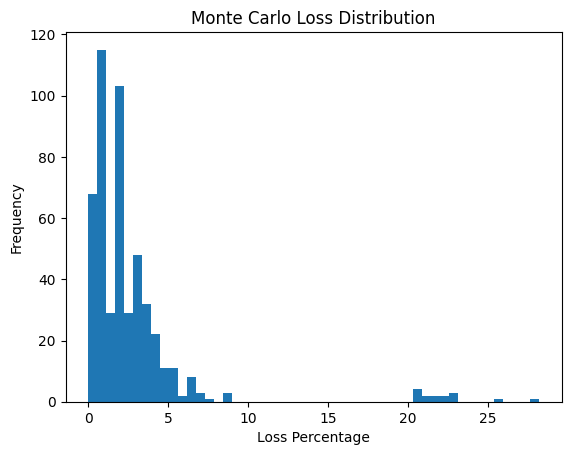

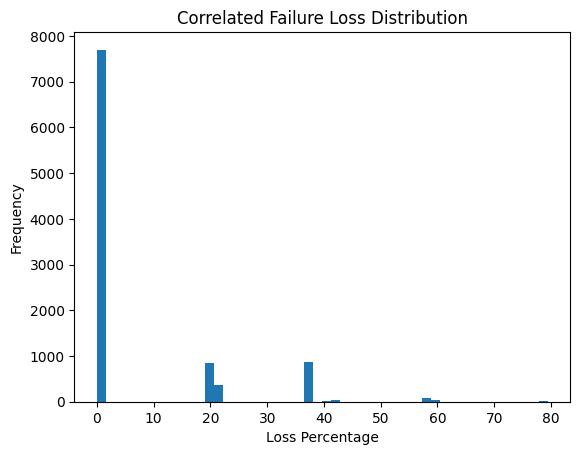

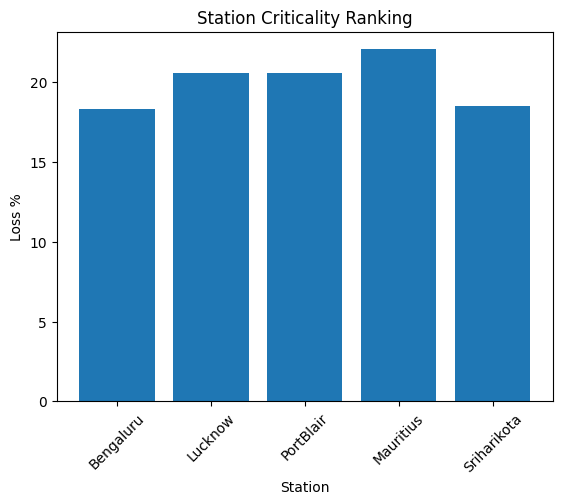

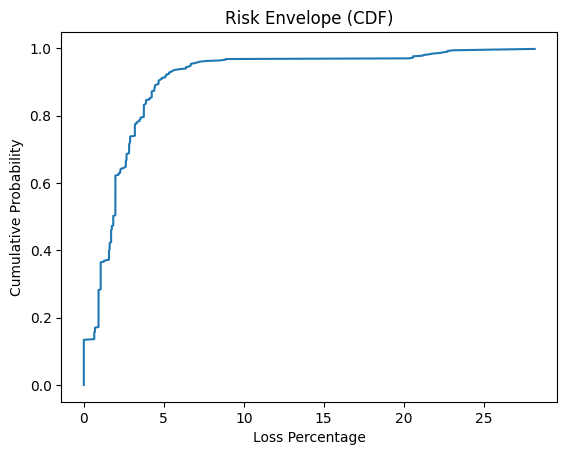

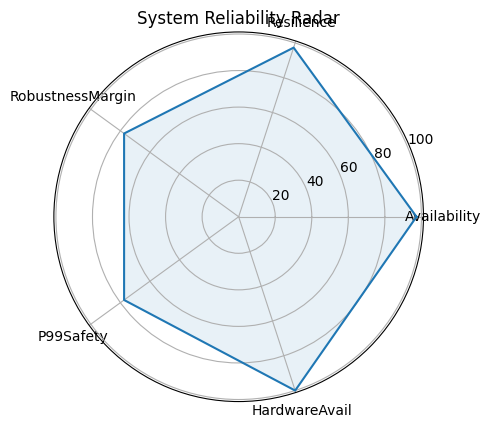

In [24]:
# Visualisation Layer

import matplotlib.pyplot as plt

plt.figure()
plt.hist(loss_distribution, bins=50)
plt.xlabel("Loss Percentage")
plt.ylabel("Frequency")
plt.title("Monte Carlo Loss Distribution")
plt.show()

plt.figure()
plt.hist(correlated_scenarios, bins=50)
plt.xlabel("Loss Percentage")
plt.ylabel("Frequency")
plt.title("Correlated Failure Loss Distribution")
plt.show()

plt.figure()
plt.bar(df_criticality["station"],
        df_criticality["loss_percent"])
plt.xlabel("Station")
plt.ylabel("Loss %")
plt.title("Station Criticality Ranking")
plt.xticks(rotation=45)
plt.show()

sorted_losses = np.sort(loss_distribution)
cdf = np.arange(len(sorted_losses)) / len(sorted_losses)

plt.figure()
plt.plot(sorted_losses, cdf)
plt.xlabel("Loss Percentage")
plt.ylabel("Cumulative Probability")
plt.title("Risk Envelope (CDF)")
plt.show()

from math import pi

metrics = {
    "Availability": availability * 100,
    "Resilience": availability * 100,
    "RobustnessMargin": robustness_margin,
    "P99Safety": 100 - np.percentile(loss_distribution, 99),
    "HardwareAvail": 99.99999999
}

labels = list(metrics.keys())
values = list(metrics.values())
values += values[:1]

angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
angles += angles[:1]

plt.figure()
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], labels)
ax.plot(angles, values)
ax.fill(angles, values, alpha=0.1)
plt.title("System Reliability Radar")
plt.show()



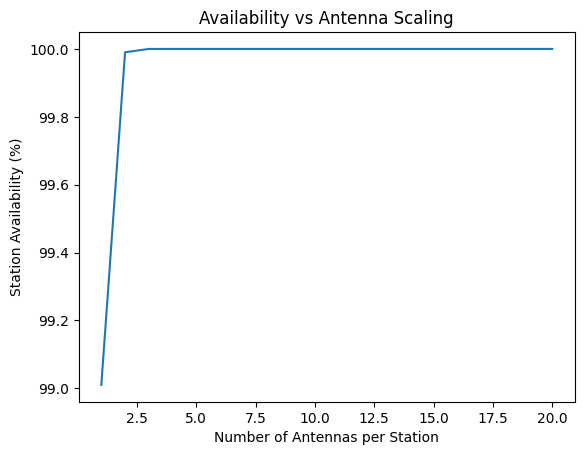

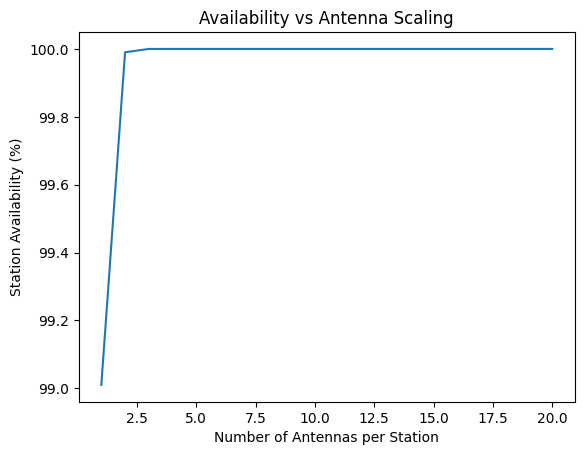

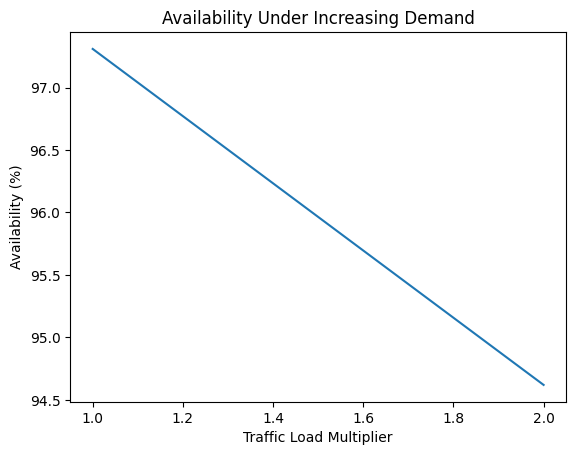

Combined Scenario Availability %: 97.30962890634969
Improved Station Availability %: 99.99999999999906


In [25]:
import numpy as np
import matplotlib.pyplot as plt

MTBF = 500
MTTR = 5

antenna_availability = MTBF / (MTBF + MTTR)

N_range = range(1, 21)
station_availability_curve = []

for N in N_range:
    A_station = 1 - (1 - antenna_availability)**N
    station_availability_curve.append(A_station * 100)

plt.figure()
plt.plot(N_range, station_availability_curve)
plt.xlabel("Number of Antennas per Station")
plt.ylabel("Station Availability (%)")
plt.title("Availability vs Antenna Scaling")
plt.show()

import numpy as np
import matplotlib.pyplot as plt

MTBF = 500
MTTR = 5

antenna_availability = MTBF / (MTBF + MTTR)

N_range = range(1, 21)
station_availability_curve = []

for N in N_range:
    A_station = 1 - (1 - antenna_availability)**N
    station_availability_curve.append(A_station * 100)

plt.figure()
plt.plot(N_range, station_availability_curve)
plt.xlabel("Number of Antennas per Station")
plt.ylabel("Station Availability (%)")
plt.title("Availability vs Antenna Scaling")
plt.show()

load_growth = np.linspace(1.0, 2.0, 10)
availability_under_load = []

for load in load_growth:
    stressed_loss = np.mean(loss_distribution) * load
    stressed_loss = min(stressed_loss, 100)
    new_availability = 1 - (stressed_loss / 100)
    availability_under_load.append(new_availability * 100)

plt.figure()
plt.plot(load_growth, availability_under_load)
plt.xlabel("Traffic Load Multiplier")
plt.ylabel("Availability (%)")
plt.title("Availability Under Increasing Demand")
plt.show()

extra_stations = 5
load_multiplier = 1.5
extra_antennas = 2

# New mean loss reduced by station addition
new_mean_loss = np.mean(loss_distribution) / (1 + 0.1 * extra_stations)

# Adjust for load
new_mean_loss *= load_multiplier

# Improved hardware redundancy
improved_antenna_avail = 1 - (1 - antenna_availability)**(5 + extra_antennas)

combined_availability = 1 - (new_mean_loss / 100)

print("Combined Scenario Availability %:",
      combined_availability * 100)
print("Improved Station Availability %:",
      improved_antenna_avail * 100)

